# h05_sub1 tiled facies inference

Run the style-matched conditional diffusion model on the irregular h05 RMS survey. Missing survey cells and partial border tiles are filled only to provide convolution context; predictions are retained exclusively at observed h05 cells.

The default settings run a small smoke test. Set `RUN_FULL_MAP = True` in Cell 2 to process every valid 64 x 64 tile. Full-map progress is checkpointed and can be resumed.

In [51]:
# 1. Set up environment and paths
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.ndimage import distance_transform_edt
from tqdm.auto import tqdm

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "style-matching" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from diffsim.core.network import Network
from diffsim.data.flumy_generator import denormalize_lithofacies

MODEL_DIR = Path("/mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional/20260811_153252")
H05_PATH = REPO_ROOT / "style-matching" / "h05_sub1"
OUTPUT_DIR = Path("/mnt/sda_data/tharitt/diffsim/results/h05_inference_20260811_153252")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PATCH_SIZE = 64
PATCH_STRIDE = 64
CLIP_PERCENTILE = 99.5
N_SAMPLES = 1
DDIM_STEPS = 10
ETA = 0.0
BATCH_SIZE = 4
RUN_FULL_MAP = True #TODO: change to test 
SMOKE_MAX_PATCHES = 20
SEED = 88

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Repository: {REPO_ROOT}")
print(f"Device: {DEVICE}")
print(f"Mode: {'full h05 map' if RUN_FULL_MAP else f'smoke test ({SMOKE_MAX_PATCHES} patches)'}")

Repository: /home/tharitt/working/DiffSim
Device: cuda
Mode: full h05 map


In [52]:
# 2. Load trained checkpoint and inference config
def load_trained_network(model_dir, device):
    with (model_dir / "config.json").open() as handle:
        config = json.load(handle)
    conditional = config["conditional"]
    unet_config = {
        "image_size": config["image_size"],
        "in_channel": conditional["in_channel"],
        "out_channel": conditional["out_channel"],
        "inner_channel": conditional["inner_channel"],
        "channel_mults": conditional["channel_mults"],
        "attn_res": conditional["attn_res"],
        "res_blocks": conditional["res_blocks"],
        "dropout": conditional["dropout"],
    }
    network = Network(
        unet=unet_config,
        beta_schedule=conditional["beta_schedule"],
        module_name=conditional.get("module_name", "guided_diffusion"),
        predict_type=conditional.get("predict_type", "epsilon"),
    ).to(device)
    network.set_new_noise_schedule(device=device, phase="test")

    checkpoint_path = model_dir / "best_model.pth"
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    state_dict = checkpoint.get("model_state", checkpoint) if isinstance(checkpoint, dict) else checkpoint
    network.load_state_dict(state_dict)
    network.eval()
    return network, config, checkpoint_path

network, config, checkpoint_path = load_trained_network(MODEL_DIR, DEVICE)
print(f"Loaded: {checkpoint_path}")
print(f"Training image size: {config['image_size']}")
print(f"UNet channels: {config['conditional']['in_channel']} -> {config['conditional']['out_channel']}")
print(f"Prediction target: {config['conditional'].get('predict_type', 'epsilon')}")

Loaded: /mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional/20260811_153252/best_model.pth
Training image size: 64
UNet channels: 2 -> 1
Prediction target: epsilon


In [53]:
# 3. Load h05_sub1 and preserve its survey-grid georeferencing
def load_h05_grid(path):
    data = np.loadtxt(path, comments="#", usecols=(0, 1, 2, 3, 4), dtype=np.float64)
    x, y, amplitude = data[:, 0], data[:, 1], data[:, 2].astype(np.float32)
    columns, rows = data[:, 3].astype(np.int32), data[:, 4].astype(np.int32)
    row_min, row_max = int(rows.min()), int(rows.max())
    col_min, col_max = int(columns.min()), int(columns.max())
    shape = (row_max - row_min + 1, col_max - col_min + 1)
    grid = np.full(shape, np.nan, dtype=np.float32)
    grid[rows - row_min, columns - col_min] = amplitude

    design = np.column_stack([np.ones(len(rows)), columns, rows])
    x_affine = np.linalg.lstsq(design, x, rcond=None)[0]
    y_affine = np.linalg.lstsq(design, y, rcond=None)[0]
    return grid, {
        "row_min": row_min,
        "row_max": row_max,
        "col_min": col_min,
        "col_max": col_max,
        "x_affine": x_affine,
        "y_affine": y_affine,
    }

rms_grid, georef = load_h05_grid(H05_PATH)
valid_grid = np.isfinite(rms_grid)
clip_value = float(np.nanpercentile(rms_grid, CLIP_PERCENTILE))
rms_clipped = np.where(valid_grid, np.minimum(rms_grid, clip_value), np.nan).astype(np.float32)

assert rms_grid.ndim == 2
assert valid_grid.any()
print(f"h05 grid: {rms_grid.shape}, observed: {valid_grid.sum():,} ({valid_grid.mean():.1%})")
print(f"RMS range: {np.nanmin(rms_grid):.2f} to {np.nanmax(rms_grid):.2f}")
print(f"Upper clip ({CLIP_PERCENTILE}%): {clip_value:.2f}")
print("X affine [offset, column, row]:", georef["x_affine"])
print("Y affine [offset, column, row]:", georef["y_affine"])

h05 grid: (5772, 1668), observed: 5,691,070 (59.1%)
RMS range: 0.00 to 3737.22
Upper clip (99.5%): 1188.94
X affine [offset, column, row]: [ 8.51456866e+05 -1.87577497e+01  1.65279068e+01]
Y affine [offset, column, row]: [ 9.73680308e+05 -1.65284260e+01 -1.87571604e+01]


In [54]:
# 4. Build an edge-safe patch extractor
def patch_origins(length, stride):
    return list(range(0, length, stride))


def extract_edge_safe_patch(grid, row0, col0, patch_size=64):
    height, width = grid.shape
    row1, col1 = min(row0 + patch_size, height), min(col0 + patch_size, width)
    patch = np.full((patch_size, patch_size), np.nan, dtype=np.float32)
    patch[: row1 - row0, : col1 - col0] = grid[row0:row1, col0:col1]
    valid = np.isfinite(patch)
    if not valid.any():
        return None

    # Nearest observed amplitude supplies context across holes and padded edges.
    nearest_indices = distance_transform_edt(~valid, return_distances=False, return_indices=True)
    filled = patch[tuple(nearest_indices)]
    observed = patch[valid]
    value_min, value_max = float(observed.min()), float(observed.max())
    if value_max - value_min < 1e-10:
        normalized = np.zeros_like(filled, dtype=np.float32)
    else:
        normalized = (2.0 * (filled - value_min) / (value_max - value_min) - 1.0).astype(np.float32)
    return normalized, valid, (row1, col1)


def build_tiles(grid, patch_size=64, stride=64):
    tiles = []
    for row0 in patch_origins(grid.shape[0], stride):
        for col0 in patch_origins(grid.shape[1], stride):
            extracted = extract_edge_safe_patch(grid, row0, col0, patch_size)
            if extracted is not None:
                tiles.append((row0, col0, *extracted))
    return tiles

all_tiles = build_tiles(rms_clipped, PATCH_SIZE, PATCH_STRIDE)
if RUN_FULL_MAP:
    tiles = all_tiles
else:
    regular_count = max(0, SMOKE_MAX_PATCHES - 1)
    # do shuffle with seed
    rng = np.random.RandomState(SEED)
    rng.shuffle(all_tiles)
    tiles = all_tiles[:regular_count] + [all_tiles[-1]]
print(f"Valid tiles: {len(all_tiles):,}; selected: {len(tiles):,}")
print(f"Last selected tile origin: {tiles[-1][0:2]}, valid pixels: {tiles[-1][3].sum():,}")

Valid tiles: 1,525; selected: 1,525
Last selected tile origin: (5760, 576), valid pixels: 268


In [55]:
# 5. Run batched inference on patches
@torch.no_grad()
def infer_batch(network, normalized_patches, n_samples, ddim_steps, eta, device):
    conditioning = torch.from_numpy(np.stack(normalized_patches)[:, None]).float().to(device)
    counts = np.zeros((len(normalized_patches), 3, PATCH_SIZE, PATCH_SIZE), dtype=np.float32)
    for _ in range(n_samples):
        generated, _ = network.restoration_ddim(
            y_cond=conditioning,
            ddim_steps=ddim_steps,
            eta=eta,
            sample_num=min(4, ddim_steps - 1),
        )
        facies = denormalize_lithofacies(generated[:, 0].cpu().numpy())
        for code in range(3):
            counts[:, code] += facies == code
    return counts / n_samples


def infer_tiles(network, tiles, output_dir, batch_size=4):
    tile_dir = output_dir / "tiles"
    tile_dir.mkdir(parents=True, exist_ok=True)
    results = []
    for start in tqdm(range(0, len(tiles), batch_size), desc="Tile batches"):
        batch_tiles = tiles[start : start + batch_size]
        batch_probabilities = [None] * len(batch_tiles)
        pending_indices, pending_patches = [], []
        for index, (row0, col0, normalized, valid, bounds) in enumerate(batch_tiles):
            tile_path = tile_dir / f"tile_r{row0:04d}_c{col0:04d}.npz"
            if tile_path.exists():
                batch_probabilities[index] = np.load(tile_path)["probabilities"]
            else:
                pending_indices.append(index)
                pending_patches.append(normalized)
        if pending_patches:
            inferred = infer_batch(network, pending_patches, N_SAMPLES, DDIM_STEPS, ETA, DEVICE)
            for index, probabilities in zip(pending_indices, inferred):
                row0, col0, _, valid, bounds = batch_tiles[index]
                np.savez_compressed(
                    tile_dir / f"tile_r{row0:04d}_c{col0:04d}.npz",
                    probabilities=probabilities,
                    valid=valid,
                    bounds=np.asarray(bounds),
                )
                batch_probabilities[index] = probabilities
        results.extend(zip(batch_tiles, batch_probabilities))
    return results

inferred_tiles = infer_tiles(network, tiles, OUTPUT_DIR, BATCH_SIZE)
print(f"Inferred or resumed {len(inferred_tiles)} tiles")

Tile batches: 100%|██████████| 382/382 [00:45<00:00,  8.41it/s]

Inferred or resumed 1525 tiles


In [56]:
# 6. Reconstruct the full output using valid-pixel weighted accumulation
def reconstruct(shape, inferred_tiles):
    probability_sum = np.zeros((3, *shape), dtype=np.float32)
    weights = np.zeros(shape, dtype=np.float32)
    for tile, probabilities in inferred_tiles:
        row0, col0, _, valid, (row1, col1) = tile
        tile_height, tile_width = row1 - row0, col1 - col0
        local_valid = valid[:tile_height, :tile_width]
        probability_sum[:, row0:row1, col0:col1] += (
            probabilities[:, :tile_height, :tile_width] * local_valid[None]
        )
        weights[row0:row1, col0:col1] += local_valid

    covered = weights > 0
    probability_maps = np.full((3, *shape), np.nan, dtype=np.float32)
    probability_maps[:, covered] = probability_sum[:, covered] / weights[covered]
    most_likely = np.full(shape, -1, dtype=np.int8)
    most_likely[covered] = np.argmax(probability_maps[:, covered], axis=0).astype(np.int8)
    return probability_maps, most_likely, weights

probability_maps, most_likely, weights = reconstruct(rms_grid.shape, inferred_tiles)
covered = weights > 0
print(f"Covered observed pixels: {covered.sum():,}")
print("Predicted facies counts:", dict(zip(*np.unique(most_likely[covered], return_counts=True))))

Covered observed pixels: 5,691,070
Predicted facies counts: {np.int8(0): np.int64(1472691), np.int8(1): np.int64(2876621), np.int8(2): np.int64(1341758)}


In [57]:
# 7. Validate edge handling with targeted tests
synthetic = np.full((70, 75), np.nan, dtype=np.float32)
synthetic[2:68, 3:73] = np.arange(66 * 70, dtype=np.float32).reshape(66, 70)
synthetic[30:35, 30:35] = np.nan
synthetic_tiles = build_tiles(synthetic, patch_size=64, stride=64)

bottom_right = next(tile for tile in synthetic_tiles if tile[0] == 64 and tile[1] == 64)
row0, col0, normalized, valid, (row1, col1) = bottom_right
assert normalized.shape == (64, 64)
assert valid.shape == (64, 64)
assert (row1, col1) == synthetic.shape
assert row1 <= synthetic.shape[0] and col1 <= synthetic.shape[1]
assert valid[: row1 - row0, : col1 - col0].any()
assert not valid[row1 - row0 :, :].any()
assert not valid[:, col1 - col0 :].any()
assert np.isfinite(normalized).all()

if RUN_FULL_MAP:
    assert np.array_equal(covered, valid_grid)
else:
    assert np.all(covered <= valid_grid)
assert most_likely[~covered].max(initial=-1) == -1
assert np.isfinite(probability_maps[:, covered]).all()
assert np.allclose(probability_maps[:, covered].sum(axis=0), 1.0, atol=1e-5)
print("Edge tests passed: partial borders, interior holes, bounds, masks, and probability sums are valid.")

Edge tests passed: partial borders, interior holes, bounds, masks, and probability sums are valid.


Saved: /mnt/sda_data/tharitt/diffsim/results/h05_inference_20260811_153252/h05_inference_full.npz


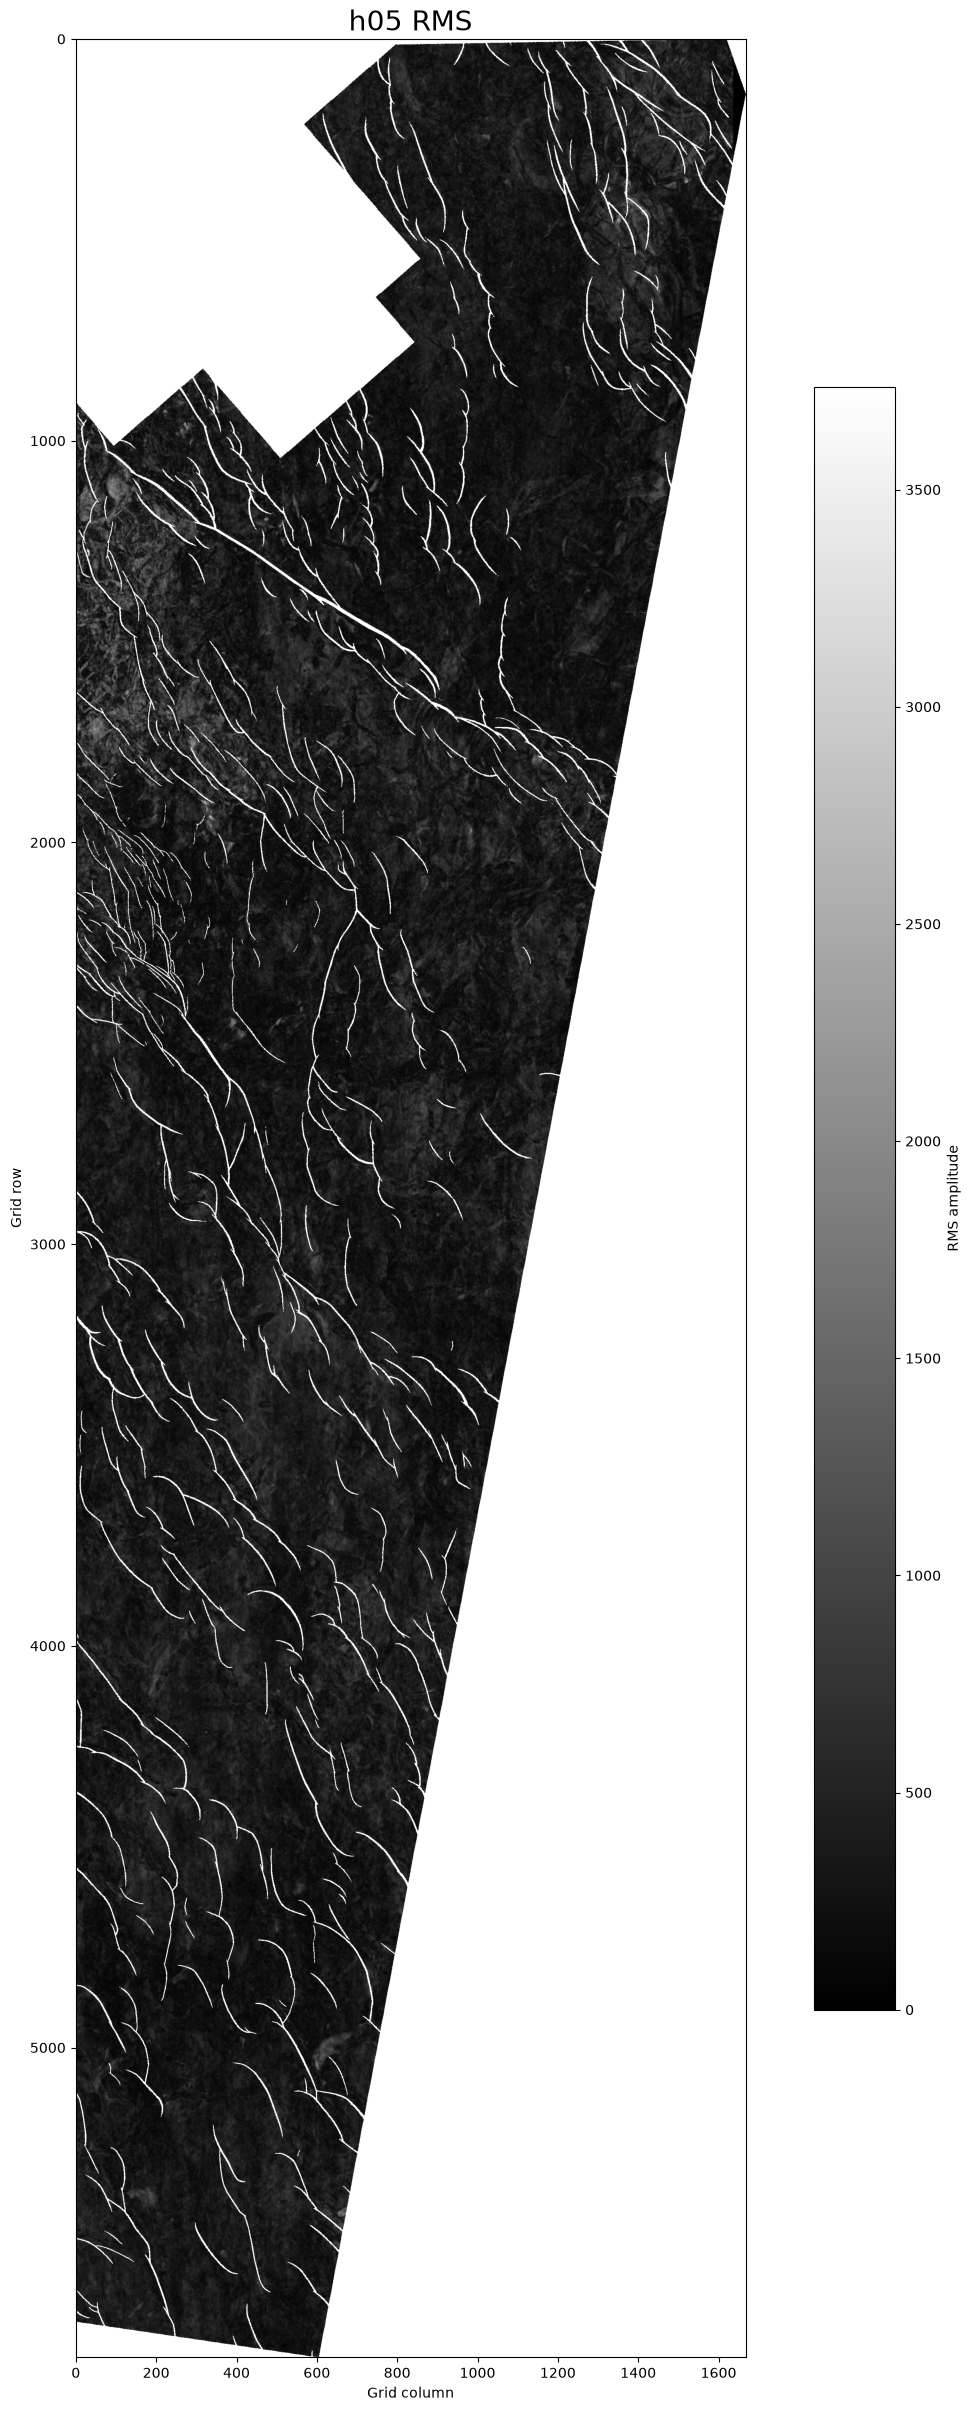

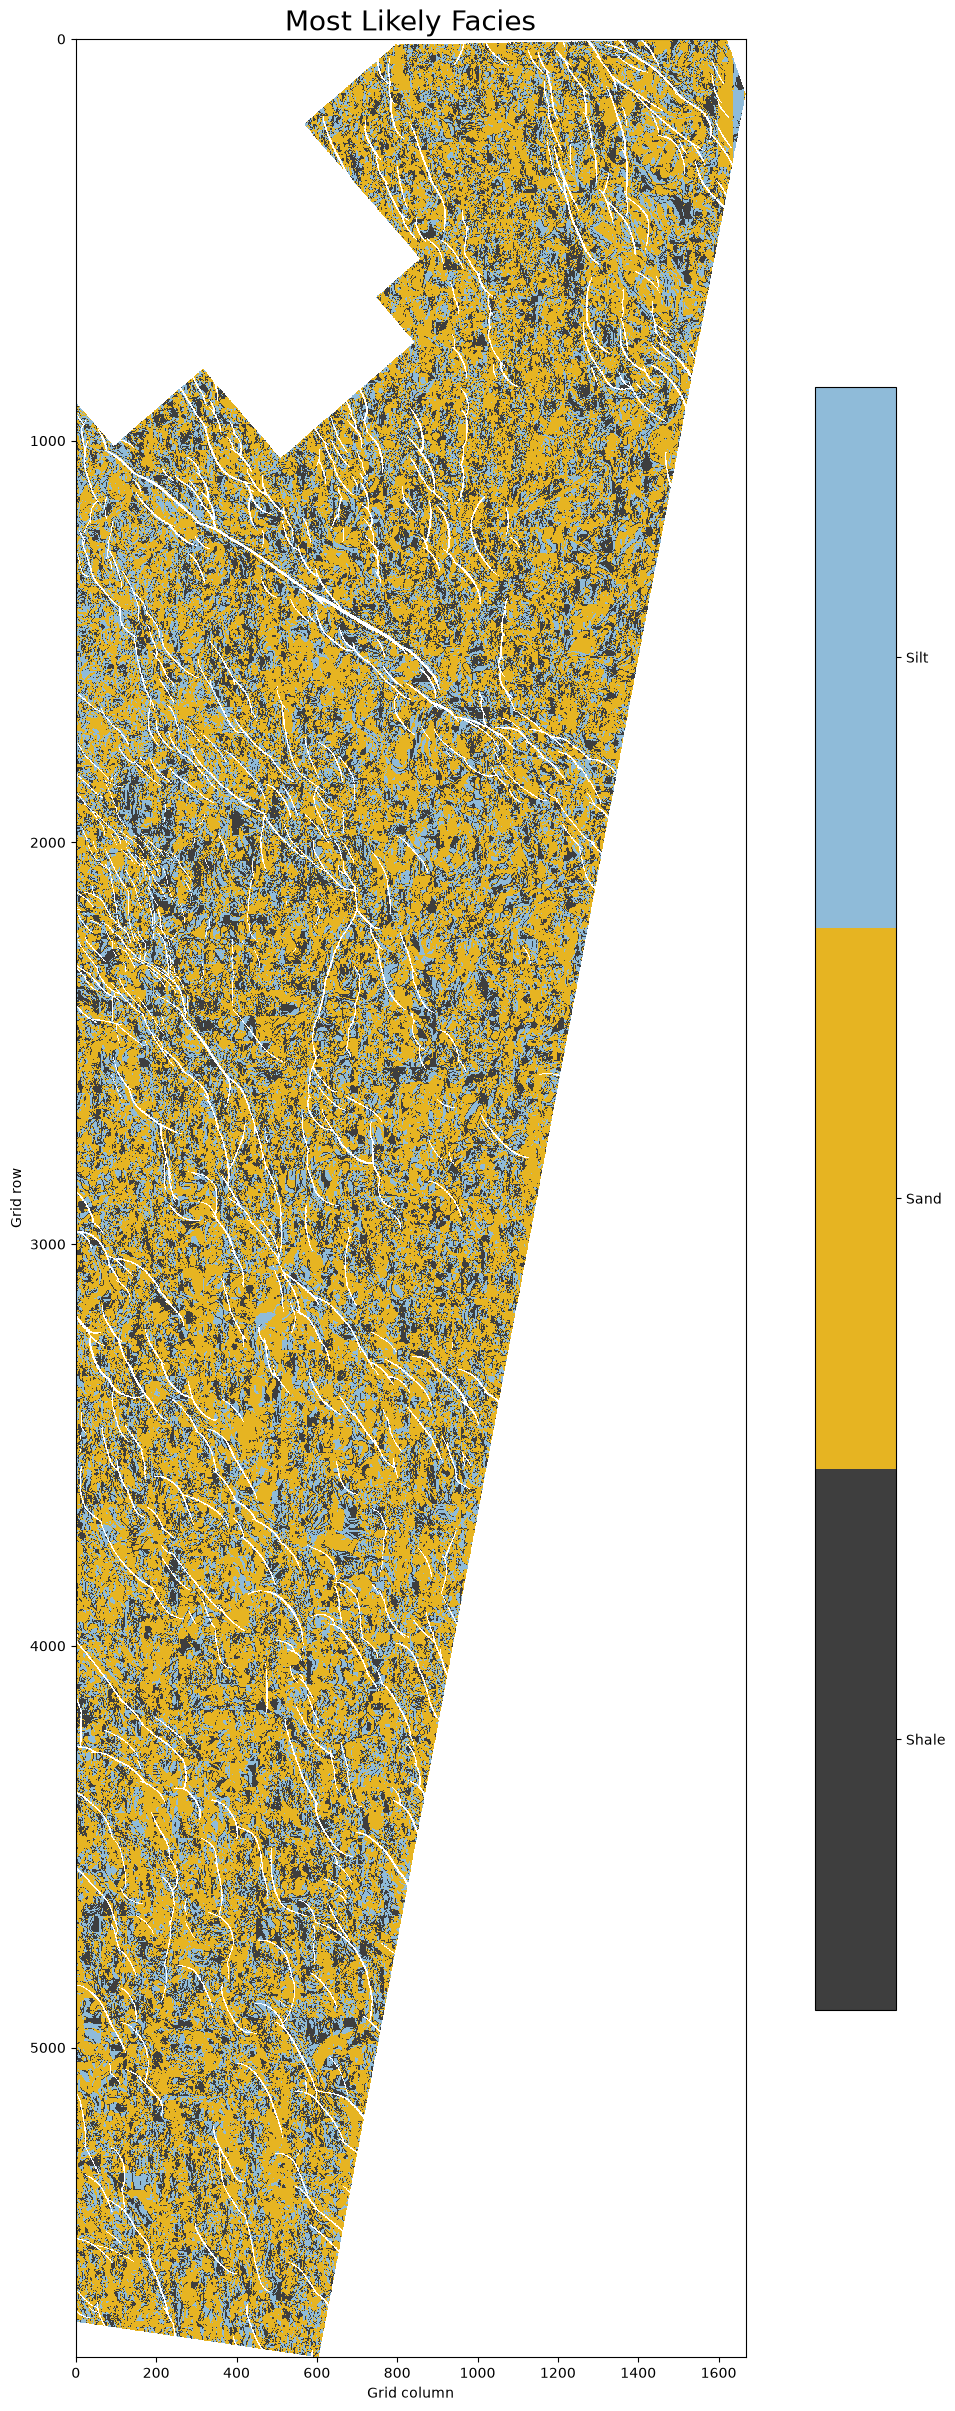

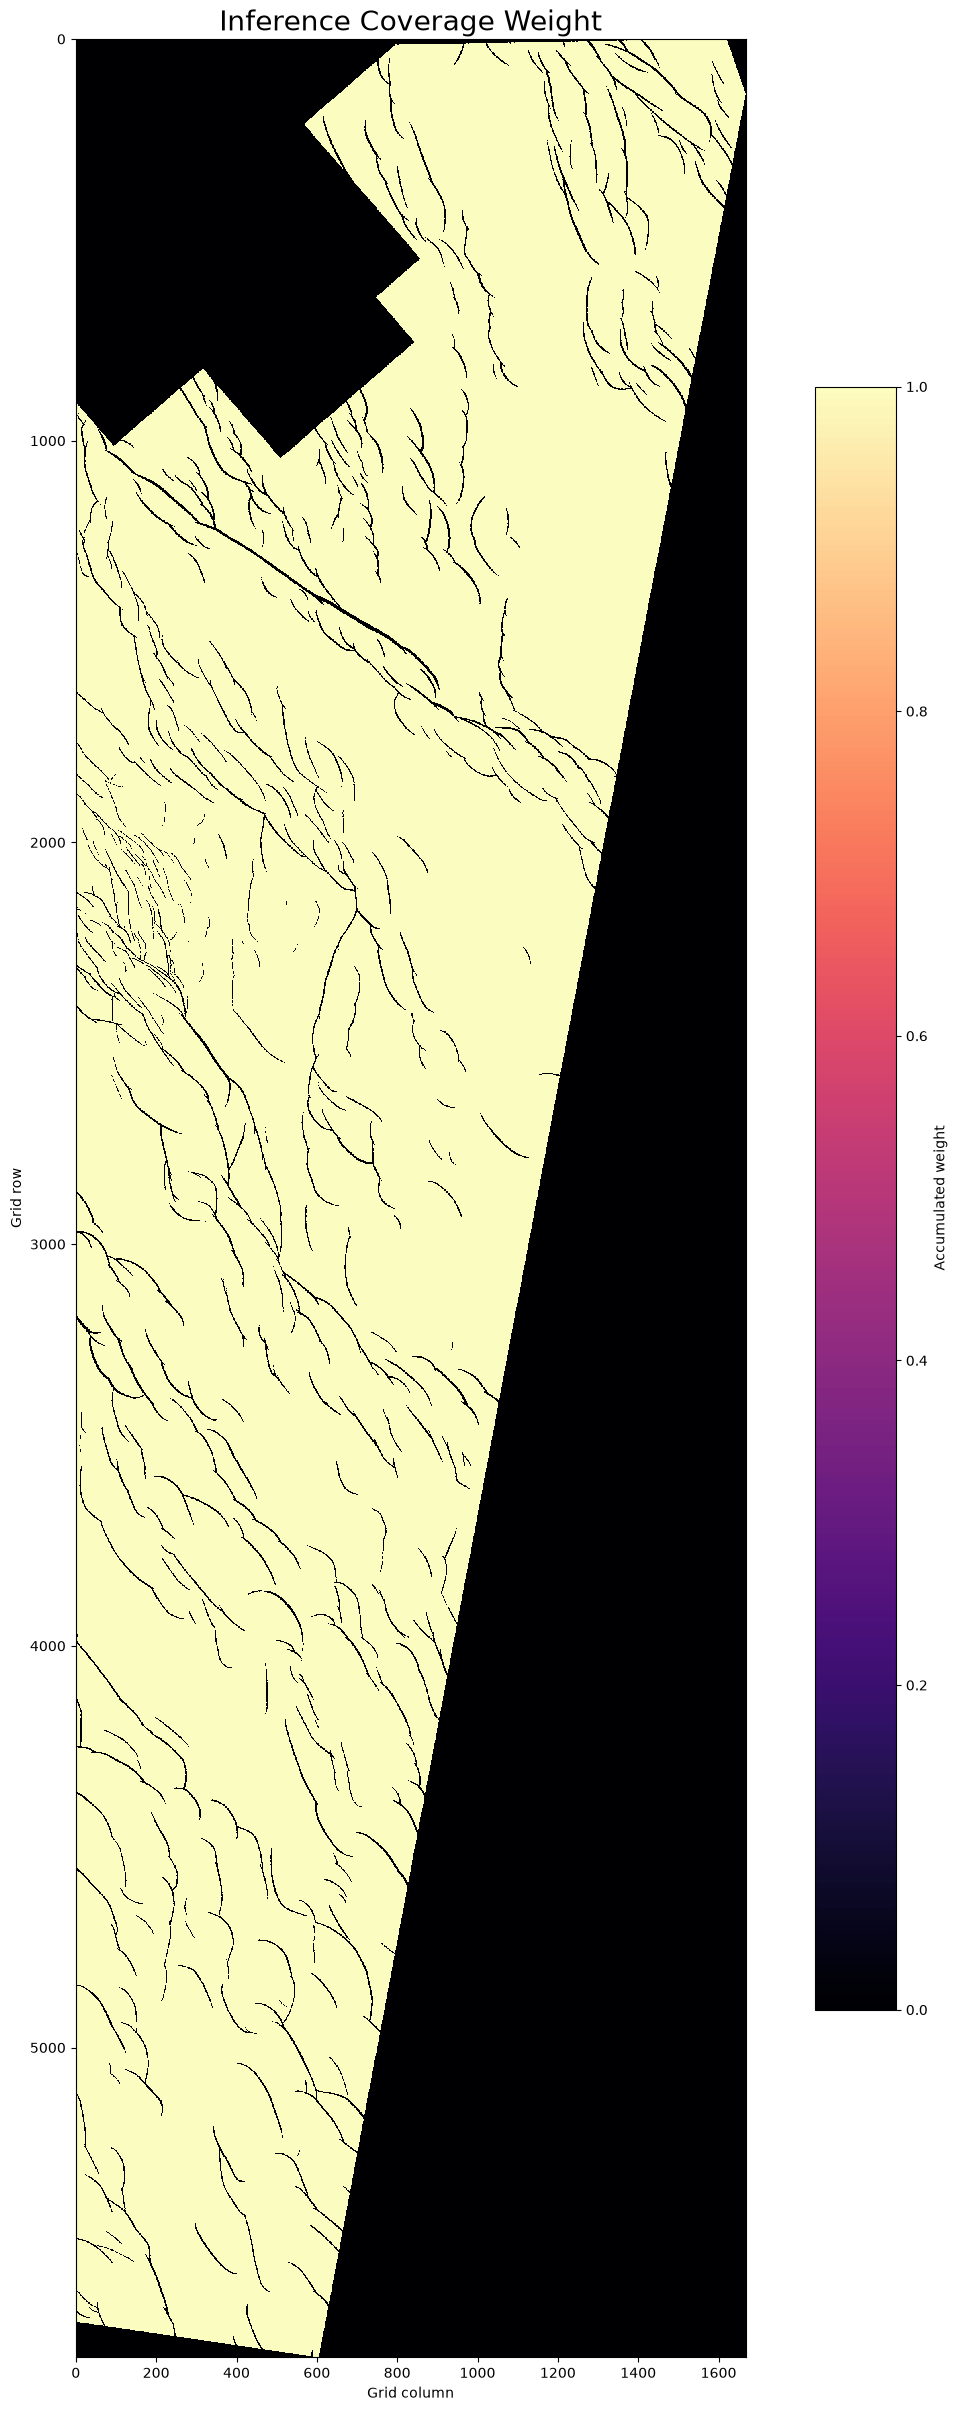

For the complete survey, set RUN_FULL_MAP=True and rerun Cells 2-9. Existing tile files are resumed automatically.


In [61]:
# 8. Save outputs and quick visual checks
mode_label = "full" if RUN_FULL_MAP else "smoke"
output_path = OUTPUT_DIR / f"h05_inference_{mode_label}.npz"
np.savez_compressed(
    output_path,
    rms=rms_grid,
    valid_mask=valid_grid,
    probabilities=probability_maps,
    most_likely=most_likely,
    weights=weights,
    row_min=georef["row_min"],
    col_min=georef["col_min"],
    x_affine=georef["x_affine"],
    y_affine=georef["y_affine"],
    facies_names=np.asarray(["shale", "sand", "silt"]),
)
print(f"Saved: {output_path}")

FACIES_NAMES = {
    0: "Shale",
    1: "Sand",
    2: "Silt",
}
FACIES_COLORS = {
    0: "#3E3E3E",
    1: "#E6B422",
    2: "#8FBBD9",
}

from matplotlib.colors import ListedColormap
facies_cmap = ListedColormap([FACIES_COLORS[i] for i in range(3)])

if RUN_FULL_MAP:
    fig, ax = plt.subplots(figsize=(16, 24), constrained_layout=True)
    rms_image = ax.imshow(rms_grid, cmap="gray", aspect="equal")
    ax.set_title("h05 RMS", fontsize=20)
    ax.set_xlabel("Grid column")
    ax.set_ylabel("Grid row")
    fig.colorbar(rms_image, ax=ax, label="RMS amplitude", shrink=0.7)
    plt.show()

    fig, ax = plt.subplots(figsize=(16, 24), constrained_layout=True)
    facies_image = ax.imshow(
        np.ma.masked_where(~covered, most_likely),
        cmap=facies_cmap,
        vmin=-0.5,
        vmax=2.5,
        aspect="equal",
        interpolation="nearest",
    )
    ax.set_title("Most Likely Facies", fontsize=20)
    ax.set_xlabel("Grid column")
    ax.set_ylabel("Grid row")
    cbar = fig.colorbar(facies_image, ax=ax, ticks=[0, 1, 2], shrink=0.7)
    cbar.ax.set_yticklabels([FACIES_NAMES[code] for code in range(3)])
    plt.show()

    fig, ax = plt.subplots(figsize=(16, 24), constrained_layout=True)
    weight_image = ax.imshow(
        weights,
        cmap="magma",
        vmin=0,
        aspect="equal",
        interpolation="nearest",
    )
    ax.set_title("Inference Coverage Weight", fontsize=20)
    ax.set_xlabel("Grid column")
    ax.set_ylabel("Grid row")
    fig.colorbar(weight_image, ax=ax, label="Accumulated weight", shrink=0.7)
    plt.show()
else:
    fig, axes = plt.subplots(len(inferred_tiles), 3, figsize=(11, 3 * len(inferred_tiles)), constrained_layout=True)
    for row, (tile, probabilities) in enumerate(inferred_tiles):
        row0, col0, normalized, valid, (row1, col1) = tile
        tile_height, tile_width = row1 - row0, col1 - col0
        observed = np.ma.masked_where(~valid, normalized)
        prediction = np.ma.masked_where(~valid, np.argmax(probabilities, axis=0))
        axes[row, 0].imshow(observed, cmap="rainbow_r", vmin=-1, vmax=1)
        axes[row, 1].imshow(prediction, cmap=facies_cmap, vmin=-0.5, vmax=2.5)
        cbar = plt.colorbar(
            plt.cm.ScalarMappable(cmap=facies_cmap, norm=plt.Normalize(vmin=-0.5, vmax=2.5)),
            ax=axes[row, 1],
            ticks=[0, 1, 2],
        )
        cbar.ax.set_yticklabels([FACIES_NAMES[i] for i in range(3)])
        axes[row, 2].imshow(valid, cmap="gray", vmin=0, vmax=1)
        axes[row, 0].set_ylabel(f"r{row0}, c{col0}\n{tile_height} x {tile_width}")
        for axis in axes[row]:
            axis.set_xticks([])
            axis.set_yticks([])
    axes[0, 0].set_title("Normalized RMS")
    axes[0, 1].set_title("Most likely facies")
    axes[0, 2].set_title("Observed-pixel mask")
    plt.show()

print("For the complete survey, set RUN_FULL_MAP=True and rerun Cells 2-9. Existing tile files are resumed automatically.")